## Loading dataset

In [1]:
!unzip MC3_release.zip

Archive:  MC3_release.zip
   creating: MC3_release/
  inflating: MC3_release/MC3_data_description.pdf  
  inflating: MC3_release/MC3_graph.json  
  inflating: MC3_release/MC3_schema.json  
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet.htm  
   creating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/colorschememapping.xml  
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/filelist.xml  
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/themedata.thmx  


In [2]:
%cd MC3_release

/content/MC3_release


In [3]:
import networkx as nx
import json

In [118]:
with open('MC3_graph.json', 'r') as f: json_data = json.load(f)
G = nx.node_link_graph(json_data, edges="edges")

## Nodes inspection

In [35]:
from IPython.display import display
display(pd.DataFrame([{'type':G.nodes[v]['type'], 'sub_type':G.nodes[v]['sub_type']} for v in G.nodes()]).value_counts().sort_index())

type          sub_type        
Entity        Group                 5
              Location             29
              Organization          5
              Person               18
              Vessel               15
Event         Assessment           36
              Collaborate          25
              Communication       584
              Criticize             1
              Enforcement          21
              Fishing               1
              HarborReport          2
              Monitoring           70
              TourActivity         13
              TransponderPing       3
              VesselMovement       46
Relationship  AccessPermission     68
              Colleagues           30
              Coordinates          74
              Friends               2
              Jurisdiction         13
              Operates             40
              Reports              25
              Suspicious           28
              Unfriendly            5
Name: count, dtype: int64

### Mini-goals of this work
- Find where there is information using conversation topics.
- Identify communication networks.
- Find where there is information using pseudonyms.

Now we just make neste dicts for easier data handling

In [70]:
map_nodes = {}
nested_info = {}
for v in G.nodes():
  map_nodes[G.nodes[v]['label']] = G.nodes[v]['type']
  if G.nodes[v]['type'] not in nested_info:
      nested_info[G.nodes[v]['type']] = {G.nodes[v]['sub_type']:[G.nodes[v]]}
      continue
  if G.nodes[v]['sub_type'] not in nested_info[G.nodes[v]['type']]:
      nested_info[G.nodes[v]['type']][G.nodes[v]['sub_type']] = [G.nodes[v]]
      continue
  nested_info[G.nodes[v]['type']][G.nodes[v]['sub_type']].append(G.nodes[v])


## Distribution of sub types by each node type identified by Clepper Jessen

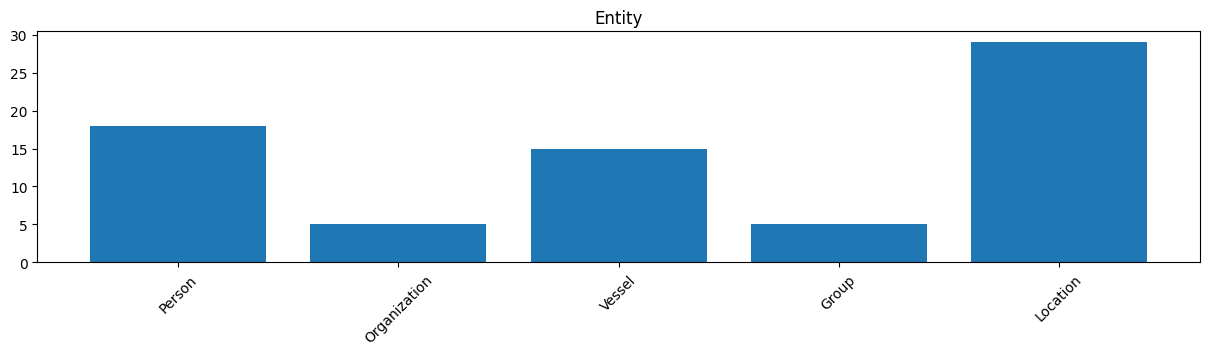

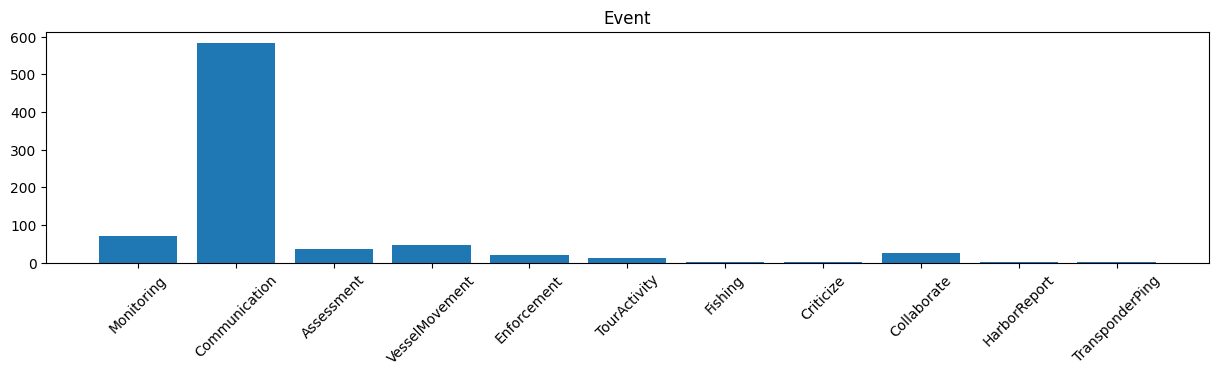

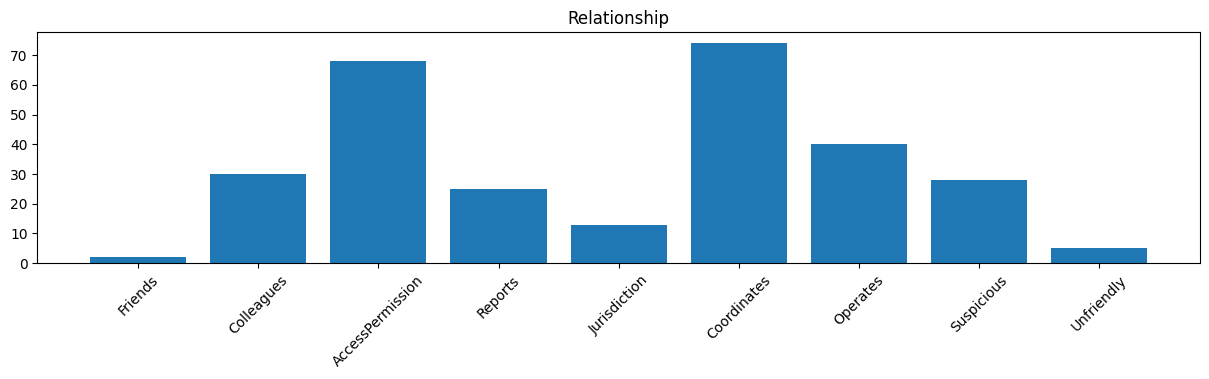

In [54]:
from matplotlib import pyplot as plt
attr = [(k,[(ki,len(vi)) for ki, vi in nested_info[k].items()]) for k,v in nested_info.items()]
for type_node, attr_i in attr:
    plt.figure(figsize=(15, 3))
    labels = [k for k,v in attr_i]
    heights = [v for k,v in attr_i]
    plt.bar(labels, heights)
    plt.title(type_node)
    plt.xticks(rotation=45)
    plt.show()
    plt.close()

## Inspection by type

In [53]:
def beauty_print(dict_info):
    for k,v in dict_info.items():
        print(f'{k} - {v}')
    print('\n')
beauty_print(nested_info['Entity']['Person'][0])
beauty_print(nested_info['Event']['Communication'][0])
beauty_print(nested_info['Relationship']['AccessPermission'][0])

type - Entity
label - Sam
name - Sam
sub_type - Person


type - Event
sub_type - Communication
label - Communication
timestamp - 2040-10-01 08:09:00
content - Hey The Intern, it's The Lookout! Just spotted a pod of dolphins near the eastern point this morning. They were so playful! If you're free this weekend, the migratory birds are starting to arrive too. Let me know if you want to join for some birdwatching!


type - Relationship
sub_type - AccessPermission
label - AccessPermission
permission_type - restricted
start_date - None
end_date - None




## Dataset generation scheme

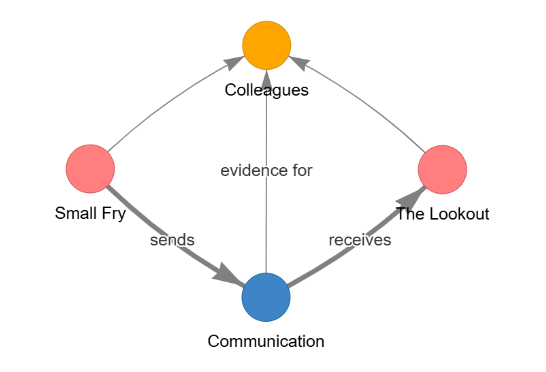

### Implicit Relationships
- Facts are communications
- Relationships and events are subject to internal and Clepper biases during graph generation

Lets review events where the hot spot person `Nadie Conti`, sent or received messages tagged as Suspicious or AccessPermission.

In [97]:
target_person = 'Nadia Conti'
target_relations = ['Suspicious', 'AccessPermission']
nodes_comm = []
suspicious_comm = []
count_bads = 0

for u, v in G.edges():
    if (target_person == v and 'Event' in u):
        uk = v; vk = u
    elif (target_person == u and 'Event' in v):
        uk = u; vk = v
    else: continue
    nodes_comm.append(vk)
    related_rel = [ui for ui in G.successors(vk) if map_nodes[G.nodes[ui]['label']] == 'Relationship' and G.nodes[ui]['sub_type'] in target_relations]
    if len(related_rel) > 0:
        print(f'{count_bads+1}')
        beauty_print(G.nodes[vk])
        suspicious_comm.append(G.nodes[vk])
        count_bads+=1
print(f'{count_bads}/{len(nodes_comm)}')

1
type - Event
sub_type - Communication
label - Communication
timestamp - 2040-10-05 09:45:00
content - Haacklee Harbor, this is Nadia Conti. I need to cancel the special access corridor arrangements for Nemo Reef immediately. Plans have changed due to unforeseen circumstances. Destroy all related documentation. I'll contact you when we're ready to proceed with alternative locations.


2
type - Event
sub_type - Communication
label - Communication
timestamp - 2040-10-08 08:18:00
content - Liam, Nadia here. Need your services urgently. Investigation brewing around Nemo Reef permits. Double your usual fee if you can ensure Harbor Master remains cooperative through next week. Meet at the usual place tomorrow, 10PM.


3
type - Event
sub_type - Communication
label - Communication
timestamp - 2040-10-05 09:44:00
content - Haacklee Harbor to Nadia Conti. Following your visit yesterday regarding the Nemo Reef event logistics, we've prepared the necessary documentation. Harbor staff is ready to 

## Text processing for insighful information

In [ ]:
import re
import pandas as pd
import spacy

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nlp = spacy.load("en_core_web_sm")

texts = [m["content"] for m in suspicious_comm]

df = pd.DataFrame({
    "text": texts
})


risk_terms = [
    "destroy documentation",
    "double your fee",
    "redirected attention",
    "suspects nothing",
    "clean up operations",
    "contingency",
    "ulterior motives",
    "special access",
    "closure",
    "payment",
    "permit",
    "cover",
    "security team",
    "facade",
    "protocols",
    "complications"
]

def risk_score(text):
    t = text.lower()
    score=0

    for term in risk_terms:
        if term in t:
            score +=2

    suspicious_patterns = [
        r"destroy.*documentation",
        r"double.*fee",
        r"bring payment",
        r"redirect.*attention",
        r"clean up operations"
    ]

    for p in suspicious_patterns:
        if re.search(p,t):
            score +=3

    return score


df["risk_score"] = df.text.apply(risk_score)

def extract_entities(text):
    doc = nlp(text)
    ents = [(e.text,e.label_) for e in doc.ents]
    return ents

df["entities"] = df.text.apply(extract_entities)
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=1
)


## Risk scoring by key pharses matching counting

In [109]:
print("MOST SUSPICIOUS:")
print(df.sort_values("risk_score", ascending=False)[["risk_score", "text"]].head(10).to_string(max_colwidth=None))

MOST SUSPICIOUS:
   risk_score                                                                                                                                                                                                                                                                                                      text
3          10                                                                    Nadia, Liam here. Meeting confirmed for tomorrow at 10PM. I've redirected Harbor Master's attention and implemented new patrol schedules that work in our favor. Council suspects nothing about Nemo Reef. Bring payment as discussed.
6           7                                                                        Nadia, Liam here. EcoVigil is questioning the ROV delay. I've redirected them to the northern quadrant, but they're suspicious about the southwest. We need to clean up operations there immediately. What's our contingency plan?
8           6                                  

## Agents identification by linguistic analysis
We are lookin only for people, organizations or locations within messages

In [130]:
entity_counter = Counter()

for ents in df.entities:
    for ent,label in ents:
        if label in ["PERSON","ORG","GPE"]:
            entity_counter[ent]+=1

print("\nFrequent entities")
for name, count_i in entity_counter.most_common(20):
    print(f'\t{name} - {count_i}')


Frequent entities
	Nadia - 8
	Nemo Reef - 5
	Liam - 3
	Haacklee Harbor - 2
	Nadia Conti - 2
	Davis - 2
	Harbor Master - 1
	Harbor Master's - 1
	Sam - 1
	V. Miesel's - 1
	City Council - 1
	Maritime Authority - 1
	EcoVigil - 1
	ROV - 1
	Mako - 1
	V. Miesel - 1
	Remora - 1


## Connecting entities by message

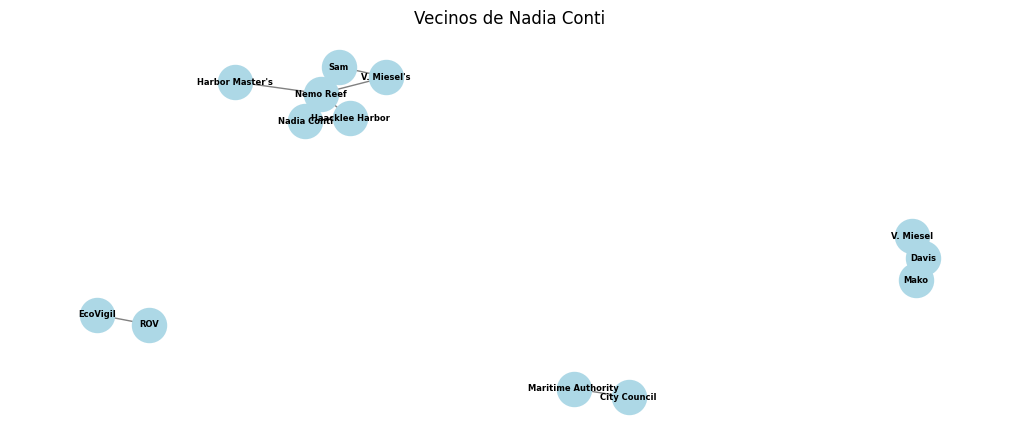

In [115]:
import itertools

G_entities = nx.Graph()

for idx, ents in enumerate(df.entities):
    people = [
        e for e,l in ents
        if l in ["PERSON","ORG"]
    ]

    for a,b in itertools.combinations(set(people),2):
        if G_entities.has_edge(a,b):
            G_entities[a][b]["weight"]+=1
        else:
            G_entities.add_edge(a,b,weight=1)

pos = nx.spring_layout(G_entities, seed=42)

plt.figure(figsize=(10, 4))
nx.draw(G_entities, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=600,
        font_size=6,
        font_weight="bold",
        edge_color="gray")
plt.title(f"Vecinos de {target_person}")
plt.axis("off")
plt.show()

## Topic analysis by word importance

In [131]:
X = vectorizer.fit_transform(df.text)
terms = vectorizer.get_feature_names_out()
print('MESSAGES, words importance')
for i,row in enumerate(X):
    scores = zip(terms,row.toarray()[0])
    top = sorted(scores,key=lambda x:x[1],reverse=True)[:10]

    print("Message ",i+1)
    for k_i, i_r in top:
        print(f'\t{k_i}={i_r:.2f}')
    print('\n')


MESSAGES, words importance
Message  1
	alternative=0.15
	alternative locations=0.15
	arrangements nemo=0.15
	cancel=0.15
	cancel special=0.15
	changed=0.15
	changed unforeseen=0.15
	circumstances=0.15
	circumstances destroy=0.15
	contact=0.15


Message  2
	usual=0.31
	brewing=0.15
	brewing nemo=0.15
	cooperative=0.15
	cooperative week=0.15
	double=0.15
	double usual=0.15
	ensure=0.15
	ensure harbor=0.15
	fee=0.15


Message  3
	harbor=0.19
	arrangements discussed=0.15
	confirm=0.15
	confirm timeline=0.15
	conti following=0.15
	discussed confirm=0.15
	documentation harbor=0.15
	event=0.15
	event logistics=0.15
	facilitate=0.15


Message  4
	10pm ve=0.16
	attention=0.16
	attention implemented=0.16
	bring=0.16
	bring payment=0.16
	confirmed tomorrow=0.16
	council suspects=0.16
	favor=0.16
	favor council=0.16
	implemented=0.16


Message  5
	clarification=0.14
	clarification real=0.14
	concrete=0.14
	concrete forms=0.14
	confirmed nemo=0.14
	construction=0.14
	construction confirmed=0.14
	co

## Topic descomposition based on dirichlet ditribution

In [138]:
lda = LatentDirichletAllocation(
    n_components=3,
    random_state=0
)

lda.fit(X)

print('TOPICS')
for i,topic in enumerate(lda.components_):
    words = [(terms[j], topic[j]) for j in topic.argsort()[-10:][::-1]]
    print(f"\nTopic {i}")
    for t_i, s_i in words:
        print(f"\tComponent {t_i} - Score {s_i:.3f}")


TOPICS

Topic 0
	Component meeting - Score 0.644
	Component 0600 - Score 0.612
	Component permit cr - Score 0.612
	Component tonight - Score 0.612
	Component cr 7844 - Score 0.612
	Component davis - Score 0.612
	Component cr - Score 0.612
	Component permit - Score 0.612
	Component 7844 - Score 0.612
	Component miesel - Score 0.598

Topic 1
	Component ve - Score 0.694
	Component harbor - Score 0.634
	Component redirected - Score 0.621
	Component nadia liam - Score 0.621
	Component ve redirected - Score 0.621
	Component discussed - Score 0.594
	Component liam - Score 0.587
	Component nadia - Score 0.513
	Component contingency - Score 0.511
	Component suspicious - Score 0.511

Topic 2
	Component usual - Score 0.641
	Component harbor - Score 0.536
	Component nemo reef - Score 0.521
	Component reef - Score 0.521
	Component nemo - Score 0.521
	Component nadia - Score 0.504
	Component need - Score 0.499
	Component circumstances - Score 0.487
	Component circumstances destroy - Score 0.487
	Com